# Baseline Models for Binary Image-Text Matching

## Introduction

This notebook builds the first baseline models for the binary image-text matching task.

The prepared dataset contains image-caption pairs labeled as:

- `1` — the caption matches the image
- `0` — the caption does not match the image

The goal of this notebook is to establish simple reference models before moving to more advanced neural architectures.

Baseline models are important because they provide a minimum performance level that future models should outperform.

## Setup & Imports

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

In [ ]:
import pandas as pd

from src.data.loaders import load_flickr30k_splits
from src.config import (
    DATASET_NAME,
    TRAIN_SPLIT,
    VAL_SPLIT,
    TEST_SPLIT,
)
from src.data.preparation import prepare_binary_dataset

## Loading and Preparing the Dataset

The same data preparation pipeline from [the previous notebook](https://github.com/Maxstef/flickr30k-multimodal-retrieval/blob/main/notebooks/02_dataset_preparation.ipynb) is reused here to generate balanced binary image-caption datasets.

In [ ]:
train_data, val_data, test_data = load_flickr30k_splits(
    DATASET_NAME,
    train_split=TRAIN_SPLIT,
    val_split=VAL_SPLIT,
    test_split=TEST_SPLIT,
)

In [4]:
train_pairs = prepare_binary_dataset(
    train_data,
    seed=RANDOM_SEED,
)

val_pairs = prepare_binary_dataset(
    val_data,
    seed=RANDOM_SEED,
)

test_pairs = prepare_binary_dataset(
    test_data,
    seed=RANDOM_SEED,
)

train_pairs.shape, val_pairs.shape

((290000, 4), (10140, 4))

## Baseline 0: Text-Only Logistic Regression

As an initial sanity check, a Logistic Regression classifier is trained using only the caption text represented by TF-IDF features.

Because the image is intentionally excluded, this baseline is expected to perform poorly. Its purpose is not to achieve high accuracy, but rather to verify whether the binary labels can be inferred from textual information alone.

If the model performs close to random guessing, it confirms that image information is essential for solving the image-text matching task.


In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import numpy as np

In [6]:
# Prepare features
X_train_text = train_pairs["caption"]
y_train = train_pairs["label"]

X_val_text = val_pairs["caption"]
y_val = val_pairs["label"]

In [7]:
# Create TF-IDF features
# use only 5000 most frequent word and bigrams
tfidf_vectorizer = TfidfVectorizer(
    lowercase=True,
    max_features=5000,
    ngram_range=(1, 2),
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_text)
X_val_tfidf = tfidf_vectorizer.transform(X_val_text)

X_train_tfidf.shape, X_val_tfidf.shape

((290000, 5000), (10140, 5000))

In [8]:
# Train model
text_baseline_model = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_SEED,
)

text_baseline_model.fit(X_train_tfidf, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [9]:
# Evaluate
y_val_pred = text_baseline_model.predict(X_val_tfidf)

metrics = {
    "accuracy": accuracy_score(y_val, y_val_pred),
    "precision": precision_score(y_val, y_val_pred),
    "recall": recall_score(y_val, y_val_pred),
    "f1": f1_score(y_val, y_val_pred),
}

metrics

/opt/miniconda3/envs/flickr30k/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


{'accuracy': 0.5, 'precision': 0.0, 'recall': 0.0, 'f1': 0.0}

In [10]:
# Detailed report
print(classification_report(y_val, y_val_pred))

              precision    recall  f1-score   support

           0       0.50      1.00      0.67      5070
           1       0.00      0.00      0.00      5070

    accuracy                           0.50     10140
   macro avg       0.25      0.50      0.33     10140
weighted avg       0.25      0.50      0.33     10140



/opt/miniconda3/envs/flickr30k/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/miniconda3/envs/flickr30k/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/miniconda3/envs/flickr30k/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()}

In [11]:
np.unique(y_val_pred, return_counts=True)

(array([0]), array([10140]))

### Observation

The model predicts only the negative class, resulting in an accuracy of 50% on the balanced validation set and an F1-score of 0 for the positive class.

Although this may initially appear to indicate a poor model, it actually validates the dataset design. The binary label depends on the relationship between an image and its caption rather than on the caption text alone. Consequently, a text-only model cannot distinguish between matching and non-matching pairs.

This experiment demonstrates that meaningful image representations must be incorporated into subsequent models, making it an appropriate baseline before introducing multimodal approaches.


## Baseline 1: Classical Multimodal Model

This baseline combines visual and textual features using a classical machine learning approach.

Images are represented using frozen ResNet18 features pretrained on ImageNet, while captions are represented using TF-IDF vectors. The image and text features are concatenated and used to train a Logistic Regression classifier.

Unlike the text-only baseline, this model has access to both modalities and can therefore learn relationships between image content and captions.

A pretrained ResNet18 is used as a fixed feature extractor rather than training a CNN from scratch. This keeps the baseline computationally efficient while providing high-quality visual representations. Training a CNN from scratch would significantly increase the complexity of the model and is better suited for the neural network models developed later in this project.


In [12]:
import torch
from scipy.sparse import hstack, csr_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

from src.features.image_features import (
    get_resnet18_feature_extractor,
    get_resnet18_transforms,
    extract_image_features,
)

from src.features.text_features import create_tfidf_vectorizer

## Image Feature Extraction

To represent images in the baseline model, a pretrained ResNet18 model is used as a fixed feature extractor. The final classification layer is removed, so each image is converted into a 512-dimensional feature vector.

These image features are extracted once for the train and validation splits and then reused when building the multimodal feature matrix.

In [ ]:
from src.config import DEVICE

print(f"Using device: {DEVICE}")

Using device: mps


In [15]:
image_model = get_resnet18_feature_extractor(device)
image_transform = get_resnet18_transforms()

In [16]:
train_image_features = extract_image_features(
    train_data,
    image_model,
    image_transform,
    device,
)

val_image_features = extract_image_features(
    val_data,
    image_model,
    image_transform,
    device,
)

100%|██████████| 1014/1014 [00:12<00:00, 81.73it/s]


In [17]:
len(train_image_features), len(val_image_features)

(29000, 1014)

In [18]:
# Inspect one feature vector
sample_filename = train_data["filename"][0]

train_image_features[sample_filename].shape

torch.Size([512])

### Observation

Image features were successfully extracted for all train and validation images. Each image is represented by a 512-dimensional vector produced by the frozen ResNet18 feature extractor.

These compact image embeddings can now be combined with TF-IDF caption features to train a classical multimodal classifier.

## Text Feature Extraction

Captions are represented using TF-IDF features. Unlike neural language models, TF-IDF does not understand word order or deep semantics, but it provides a simple and efficient baseline representation for classical machine learning models.

In [19]:
from src.features.text_features import create_tfidf_vectorizer

tfidf_vectorizer = create_tfidf_vectorizer(
    max_features=5000,
    ngram_range=(1, 1),
)

X_train_text = tfidf_vectorizer.fit_transform(train_pairs["caption"])
X_val_text = tfidf_vectorizer.transform(val_pairs["caption"])

X_train_text.shape, X_val_text.shape

((290000, 5000), (10140, 5000))

### Observation

TF-IDF converts each caption into a sparse vector representation. The vectorizer is fitted only on the training captions and then applied to the validation captions to avoid data leakage.

## Multimodal Feature Matrix

The image and text representations are combined into a single feature matrix. For each image-caption pair, the corresponding ResNet18 image embedding is concatenated with the TF-IDF caption vector.

This gives the Logistic Regression model access to both visual and textual information.

In [21]:
from src.features.image_features import (
    build_image_feature_matrix,
)

X_train_image = build_image_feature_matrix(
    train_pairs,
    train_image_features,
)

X_val_image = build_image_feature_matrix(
    val_pairs,
    val_image_features,
)

In [22]:
X_train_image.shape, X_val_image.shape

((290000, 512), (10140, 512))

In [23]:
# concatenate image + text features
X_train_multimodal = hstack(
    [X_train_image, X_train_text]
)

X_val_multimodal = hstack(
    [X_val_image, X_val_text]
)

X_train_multimodal.shape, X_val_multimodal.shape

((290000, 5512), (10140, 5512))

In [24]:
y_train = train_pairs["label"]
y_val = val_pairs["label"]

In [25]:
print("Train feature matrix:", X_train_multimodal.shape)
print("Validation feature matrix:", X_val_multimodal.shape)

print("Train labels:", y_train.shape)
print("Validation labels:", y_val.shape)

Train feature matrix: (290000, 5512)
Validation feature matrix: (10140, 5512)
Train labels: (290000,)
Validation labels: (10140,)


## Training Logistic Regression

The concatenated multimodal feature matrix is used to train a Logistic Regression classifier. This model serves as a classical machine learning baseline, combining pretrained visual features from ResNet18 with TF-IDF text representations.

The objective is to evaluate whether a simple linear classifier can learn to distinguish matching and non-matching image-caption pairs before introducing more expressive neural network architectures.


In [28]:
log_reg = LogisticRegression(
    random_state=RANDOM_SEED,
    max_iter=1000,
)

In [29]:
log_reg.fit(
    X_train_multimodal,
    y_train,
)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [30]:
# prediction
y_pred = log_reg.predict(
    X_val_multimodal,
)

In [31]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

results = {
    "Accuracy": accuracy_score(y_val, y_pred),
    "Precision": precision_score(y_val, y_pred),
    "Recall": recall_score(y_val, y_pred),
    "F1-score": f1_score(y_val, y_pred),
}

pd.Series(results)

/opt/miniconda3/envs/flickr30k/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Accuracy     0.5
Precision    0.0
Recall       0.0
F1-score     0.0
dtype: float64

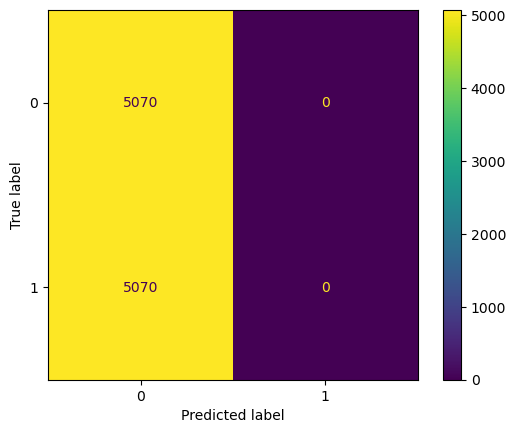

In [33]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_val,
    y_pred,
);

### Observation

The Logistic Regression model predicts only the negative class, resulting in an accuracy of 50% on the balanced validation set and an F1-score of 0 for the positive class.

Although the model receives both image and text features, it remains a linear classifier operating on the concatenated feature vector. As a result, it cannot effectively model the relationship between the two modalities required for image-text matching.

This experiment demonstrates that simply combining pretrained image embeddings with TF-IDF features is insufficient for this task. More expressive models capable of learning interactions between image and text representations are required, providing the motivation for the neural multimodal models developed in the following notebooks.


## Baseline 2: Training MLP Classifier

Since Logistic Regression is a linear model, it cannot effectively learn interactions between image and text features. As a stronger baseline, a small Multi-Layer Perceptron (MLP) classifier is trained on the same concatenated multimodal feature matrix.

Unlike Logistic Regression, the MLP includes hidden layers with non-linear activations, allowing it to model more complex relationships between image and caption representations.

In [41]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

def get_mlp_model(
    hidden_layer_sizes=(64,),
    learning_rate_init=1e-3,
    max_iter=10,
):
    return MLPClassifier(
        hidden_layer_sizes=hidden_layer_sizes,
        activation="relu",
        solver="adam",
        batch_size=256,
        learning_rate_init=learning_rate_init,
        max_iter=max_iter,
        random_state=RANDOM_SEED,
        verbose=True,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=3,
    )


In [42]:
# first try on subset
mlp_subset = get_mlp_model()
subset_size = 50_000

X_train_subset = X_train_multimodal[:subset_size]
y_train_subset = y_train.iloc[:subset_size]

mlp_subset.fit(X_train_subset, y_train_subset)

Iteration 1, loss = 0.69800914
Validation score: 0.507800
Iteration 2, loss = 0.69328695
Validation score: 0.503600
Iteration 3, loss = 0.69277626
Validation score: 0.503000
Iteration 4, loss = 0.69232964
Validation score: 0.506200
Iteration 5, loss = 0.69114410
Validation score: 0.513000
Iteration 6, loss = 0.68757751
Validation score: 0.519600
Iteration 7, loss = 0.68122797
Validation score: 0.521000
Iteration 8, loss = 0.67211946
Validation score: 0.557200
Iteration 9, loss = 0.65766738
Validation score: 0.583200
Iteration 10, loss = 0.64068626
Validation score: 0.610200


/opt/miniconda3/envs/flickr30k/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(


,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(64,)"
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",256
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",10
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"verbose verbose: bool, default=FalseWhether to print progress messages to stdout.",True
,"early_stopping early_stopping: bool, default=FalseWhether to use early stopping to terminate training when validationscore is not improving. If set to True, it will automatically setaside ``validation_fraction`` of training data as validation andterminate training when validation score is not improving by at least``tol`` for ``n_iter_no_change`` consecutive epochs. The split isstratified, except in a multilabel setting.If early stopping is False, then the training stops when the trainingloss does not improve by more than ``tol`` for ``n_iter_no_change``consecutive passes over the training set.Only effective when solver='sgd' or 'adam'.",True
,"n_iter_no_change n_iter_no_change: int, default=10Maximum number of epochs to not meet ``tol`` improvement.Only effective when solver='sgd' or 'adam'... versionadded:: 0.20",3
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score 

looks like it finally learns something :)

In [43]:
y_val_pred_mlp_subset = mlp_subset.predict(X_val_multimodal)

mlp_subset_results = {
    "Accuracy": accuracy_score(y_val, y_val_pred_mlp_subset),
    "Precision": precision_score(y_val, y_val_pred_mlp_subset),
    "Recall": recall_score(y_val, y_val_pred_mlp_subset),
    "F1-score": f1_score(y_val, y_val_pred_mlp_subset),
}

pd.Series(mlp_subset_results)

Accuracy     0.600986
Precision    0.603560
Recall       0.588560
F1-score     0.595966
dtype: float64

In [ ]:
# increase max_iter a bit
mlp = get_mlp_model(max_iter=20)

In [45]:
%%time
# train on full train data - might be timeconsuming
mlp.fit(X_train_multimodal, y_train)

Iteration 1, loss = 0.69352864
Validation score: 0.540966
Iteration 2, loss = 0.66473764
Validation score: 0.585759
Iteration 3, loss = 0.63765160
Validation score: 0.593414
Iteration 4, loss = 0.62704925
Validation score: 0.592310
Iteration 5, loss = 0.62159142
Validation score: 0.599172
Iteration 6, loss = 0.61717417
Validation score: 0.595069
Iteration 7, loss = 0.61477747
Validation score: 0.601241
Iteration 8, loss = 0.61137326
Validation score: 0.592345
Iteration 9, loss = 0.61007959
Validation score: 0.602517
Iteration 10, loss = 0.60829411
Validation score: 0.598828
Iteration 11, loss = 0.60635446
Validation score: 0.603345
Iteration 12, loss = 0.60468714
Validation score: 0.605000
Iteration 13, loss = 0.60070130
Validation score: 0.609276
Iteration 14, loss = 0.59501842
Validation score: 0.618276
Iteration 15, loss = 0.59121217
Validation score: 0.629621
Iteration 16, loss = 0.58814338
Validation score: 0.632448
Iteration 17, loss = 0.58594569
Validation score: 0.626552
Iterat

/opt/miniconda3/envs/flickr30k/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(64,)"
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",256
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",20
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"verbose verbose: bool, default=FalseWhether to print progress messages to stdout.",True
,"early_stopping early_stopping: bool, default=FalseWhether to use early stopping to terminate training when validationscore is not improving. If set to True, it will automatically setaside ``validation_fraction`` of training data as validation andterminate training when validation score is not improving by at least``tol`` for ``n_iter_no_change`` consecutive epochs. The split isstratified, except in a multilabel setting.If early stopping is False, then the training stops when the trainingloss does not improve by more than ``tol`` for ``n_iter_no_change``consecutive passes over the training set.Only effective when solver='sgd' or 'adam'.",True
,"n_iter_no_change n_iter_no_change: int, default=10Maximum number of epochs to not meet ``tol`` improvement.Only effective when solver='sgd' or 'adam'... versionadded:: 0.20",3
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score 

In [ ]:
# first, check train data prediction results
y_train_pred_mlp = mlp.predict(X_train_multimodal)

mlp_train_results = {
    "Accuracy Train": accuracy_score(y_train, y_train_pred_mlp),
    "Precision Train": precision_score(y_train, y_train_pred_mlp),
    "Recall Train": recall_score(y_train, y_train_pred_mlp),
    "F1-score Train": f1_score(y_train, y_train_pred_mlp),
}

pd.Series(mlp_train_results)

Accuracy Train     0.661334
Precision Train    0.732270
Recall Train       0.508634
F1-score Train     0.600300
dtype: float64

In [46]:
y_val_pred_mlp = mlp.predict(X_val_multimodal)

In [47]:
mlp_results = {
    "Accuracy": accuracy_score(y_val, y_val_pred_mlp),
    "Precision": precision_score(y_val, y_val_pred_mlp),
    "Recall": recall_score(y_val, y_val_pred_mlp),
    "F1-score": f1_score(y_val, y_val_pred_mlp),
}

pd.Series(mlp_results)

Accuracy     0.641124
Precision    0.714543
Recall       0.470020
F1-score     0.567043
dtype: float64

In [48]:
print(classification_report(y_val, y_val_pred_mlp))

              precision    recall  f1-score   support

           0       0.61      0.81      0.69      5070
           1       0.71      0.47      0.57      5070

    accuracy                           0.64     10140
   macro avg       0.66      0.64      0.63     10140
weighted avg       0.66      0.64      0.63     10140



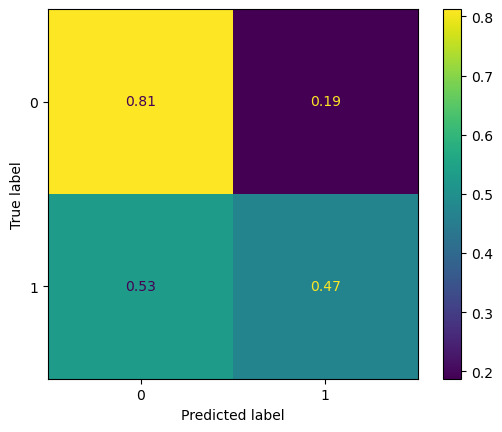

In [51]:
ConfusionMatrixDisplay.from_predictions(
    y_val,
    y_val_pred_mlp,
    normalize="true"
);

### Observation

The MLP classifier performs substantially better than both previous baselines. Unlike Logistic Regression, it successfully predicts both classes and achieves an accuracy of approximately **64%**, which is well above the **50%** expected from random guessing on a balanced dataset. This indicates that the model has learned meaningful patterns from the combined image and text representations.

However, the F1-score remains moderate, suggesting that the model still struggles to consistently identify matching image-caption pairs. This is likely because it relies on fixed ResNet18 image features and sparse TF-IDF text representations rather than jointly learned multimodal embeddings.

Overall, this experiment demonstrates that introducing non-linear interactions between image and text features significantly improves performance over linear models. At the same time, it motivates the next stage of the project: developing a neural multimodal classifier with trainable components capable of learning richer cross-modal relationships.


## Save Model & Metrics

In [80]:
from src.models.io import save_sklearn_model
from src.config import MODELS_DIR

save_sklearn_model(
    mlp,
    MODELS_DIR / "baseline_mlp.joblib",
)

save_sklearn_model(
    tfidf_vectorizer,
    MODELS_DIR / "tfidf_vectorizer.joblib",
)

In [83]:
from src.config import RESULTS_DIR

baseline_metrics = pd.DataFrame(
    [
        {
            "model": "Text-only Logistic Regression",
            "split": "validation",
            "accuracy": 0.5000,
            "precision": 0.0000,
            "recall": 0.0000,
            "f1": 0.0000,
        },
        {
            "model": "Multimodal Logistic Regression",
            "split": "validation",
            "accuracy": 0.5000,
            "precision": 0.0000,
            "recall": 0.0000,
            "f1": 0.0000,
        },
        {
            "model": "Multimodal MLP",
            "split": "train",
            "accuracy": accuracy_score(y_train, y_train_pred_mlp),
            "precision": precision_score(y_train, y_train_pred_mlp),
            "recall": recall_score(y_train, y_train_pred_mlp),
            "f1": f1_score(y_train, y_train_pred_mlp),
        },
        {
            "model": "Multimodal MLP",
            "split": "validation",
            "accuracy": accuracy_score(y_val, y_val_pred_mlp),
            "precision": precision_score(y_val, y_val_pred_mlp),
            "recall": recall_score(y_val, y_val_pred_mlp),
            "f1": f1_score(y_val, y_val_pred_mlp),
        },
    ]
)

baseline_metrics

,model,split,accuracy,precision,recall,f1
0,Text-only Logistic Regression,validation,0.500000,0.000000,0.000000,0.000000
1,Multimodal Logistic Regression,validation,0.500000,0.000000,0.000000,0.000000
2,Multimodal MLP,train,0.661334,0.732270,0.508634,0.600300
3,Multimodal MLP,validation,0.641124,0.714543,0.470020,0.567043


In [84]:
baseline_metrics.to_csv(
    RESULTS_DIR / "baseline_metrics.csv",
    index=False,
)

## Notebook Summary

In this notebook, several baseline models for image-text matching were developed and evaluated.

The experiments began with a text-only Logistic Regression model, which confirmed that caption information alone is insufficient for determining whether an image-caption pair is a match. A multimodal Logistic Regression model was then introduced by combining pretrained ResNet18 image features with TF-IDF caption features. Despite using both modalities, the linear classifier was unable to learn the required relationships between images and text.

Finally, a Multi-Layer Perceptron (MLP) classifier was trained on the same multimodal feature representation. By introducing non-linear interactions, the MLP achieved substantially better performance, establishing the first meaningful baseline for the project.

These experiments demonstrate the importance of modeling interactions between image and text and provide a strong motivation for the next stage of the project, where an end-to-end neural multimodal model with trainable components will be developed.
